In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

df=pd.read_csv('Project_description_and_data/claims_train.csv')

df['VehAge_1']=df['VehAge'] +1
df['VehAge_log']=np.log(df['VehAge_1'])

df['DrivAge_log']=np.log(df['DrivAge'])
df['Density_log']=np.log(df['Density'])

low_cn=df[df['ClaimNb']>1]

In [2]:
low_cn['VehGas']=np.where((low_cn['VehGas']=='Regular'), 0, 1)

features = ['ClaimNb', 'DrivAge_log', 'VehPower', 'VehAge_log', 'Density_log', 'BonusMalus']

from sklearn.preprocessing import StandardScaler

X = low_cn[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)   # for 2D visualization
X_pca = pca.fit_transform(X_scaled)

low_cn["PC1"] = X_pca[:, 0]
low_cn["PC2"] = X_pca[:, 1]

C:\Users\karat\AppData\Local\Temp\ipykernel_22500\1583373417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_cn['VehGas']=np.where((low_cn['VehGas']=='Regular'), 0, 1)
C:\Users\karat\AppData\Local\Temp\ipykernel_22500\1583373417.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_cn["PC1"] = X_pca[:, 0]
C:\Users\karat\AppData\Local\Temp\ipykernel_22500\1583373417.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

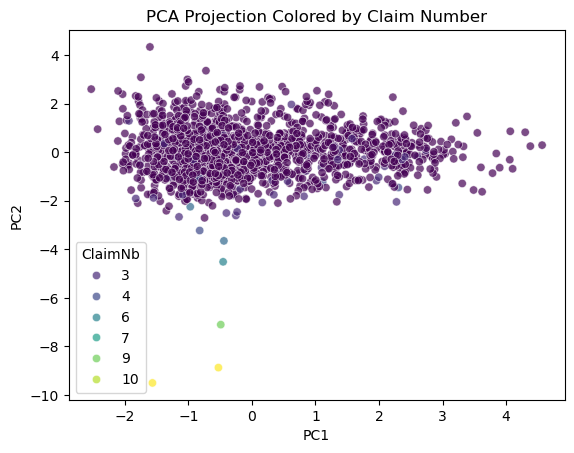

In [3]:
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="ClaimNb",
    data=low_cn,
    palette="viridis",
    alpha=0.7
)

#plt.ylim(-3, 5)
plt.title("PCA Projection Colored by Claim Number")
plt.show()

In [4]:
explained = pca.explained_variance_ratio_
print(f"PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}, Total: {explained[:2].sum():.2%}")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)
print(loadings)

PC1: 27.11%, PC2: 18.64%, Total: 45.75%
                  PC1       PC2
ClaimNb     -0.005707 -0.399182
DrivAge_log -0.647015 -0.111974
VehPower    -0.111849  0.556045
VehAge_log   0.269054 -0.475456
Density_log  0.182563  0.540620
BonusMalus   0.680522  0.024528


C:\Users\karat\AppData\Local\Temp\ipykernel_22500\1672330713.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_cn["Cluster"] = kmeans.fit_predict(X_pca)


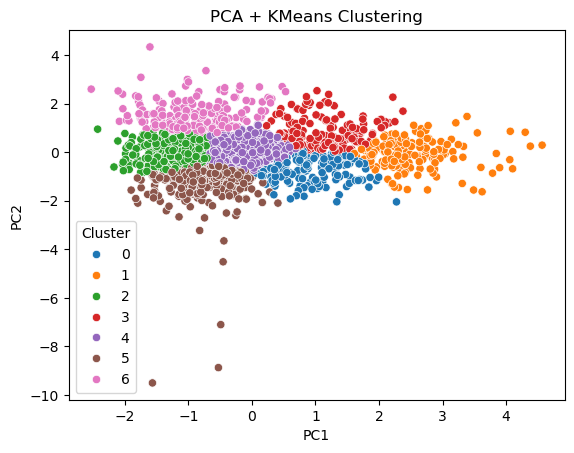

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=42)
low_cn["Cluster"] = kmeans.fit_predict(X_pca)

sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=low_cn, palette="tab10")
plt.title("PCA + KMeans Clustering")
plt.show()

In [6]:
from sklearn.cluster import DBSCAN

X_dbscan = low_cn[["PC1", "PC2"]].values
db = DBSCAN(eps=0.5, min_samples=7).fit(X_dbscan)

7


C:\Users\karat\AppData\Local\Temp\ipykernel_22500\2002063781.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


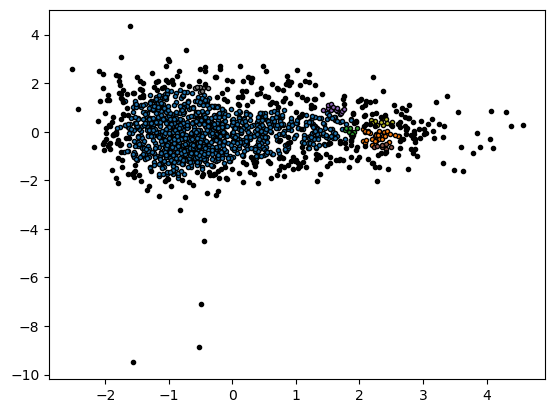

In [7]:
from sklearn.cluster import DBSCAN
X_dbscan = low_cn[["PC1", "PC2"]].values
db = DBSCAN(eps=0.19, min_samples=10).fit(X_dbscan)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print(n_clusters_)
unique_labels = set(labels)
colors = plt.cm.get_cmap('tab10', len(unique_labels))

for k, col in zip(unique_labels, colors(np.arange(len(unique_labels)))):
    if k == -1:
        col = (0, 0, 0, 1)  # black for noise

    class_member_mask = (labels == k)
    xy = X_dbscan[class_member_mask]
    
    plt.plot(xy[:, 0], xy[:, 1], 'o',
        markerfacecolor=col,
        markeredgecolor='k',
        markersize=3)

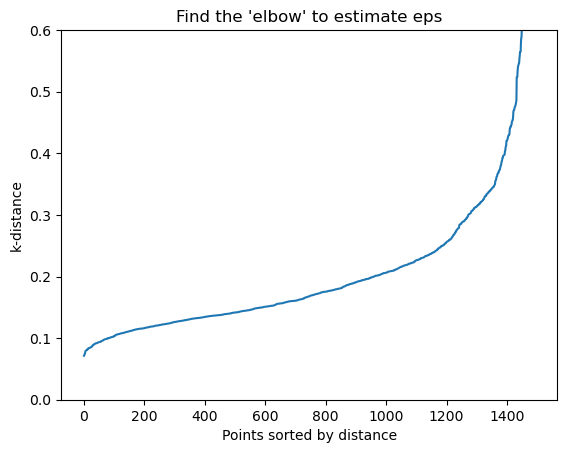

In [8]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neigh = NearestNeighbors(n_neighbors=10)  # same as your min_samples
nbrs = neigh.fit(X_dbscan)
distances, indices = nbrs.kneighbors(X_dbscan)

distances = np.sort(distances[:, 9])
plt.plot(distances)
plt.ylabel("k-distance")
plt.xlabel("Points sorted by distance")
plt.title("Find the 'elbow' to estimate eps")
plt.ylim(0,0.6)
plt.show()

In [9]:
print(f"Estimated number of clusters: {n_clusters}")

NameError: name 'n_clusters' is not defined

c:\Users\karat\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\karat\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\karat\AppData\Local\Temp\ipykernel_22500\2161062348.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_cn["cluster"] = labels
C:\Users\karat\AppData\Local\Temp\ipykernel_22500\2161062348.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colo

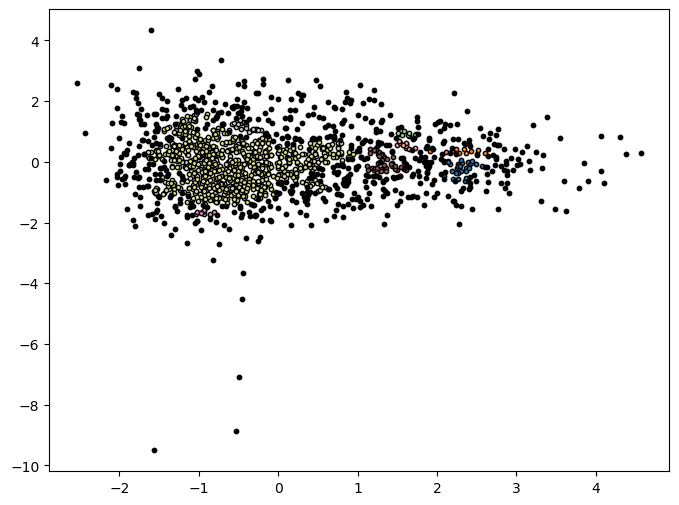

In [10]:
import hdbscan
X_hdbscan = low_cn[["PC1", "PC2"]].values
clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=8) 
labels = clusterer.fit_predict(X_hdbscan)
low_cn["cluster"] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = plt.cm.get_cmap("tab20", len(unique_labels))

plt.figure(figsize=(8,6))

for k, col in zip(unique_labels, colors(np.arange(len(unique_labels)))):
    if k == -1:
        col = (0, 0, 0, 1)  # black for noise
    
    mask = labels == k
    xy = X_hdbscan[mask]
    
    plt.scatter(xy[:,0], xy[:,1], c=[col], edgecolor='k', s=10, label=f"Cluster {k}" if k != -1 else "Noise")

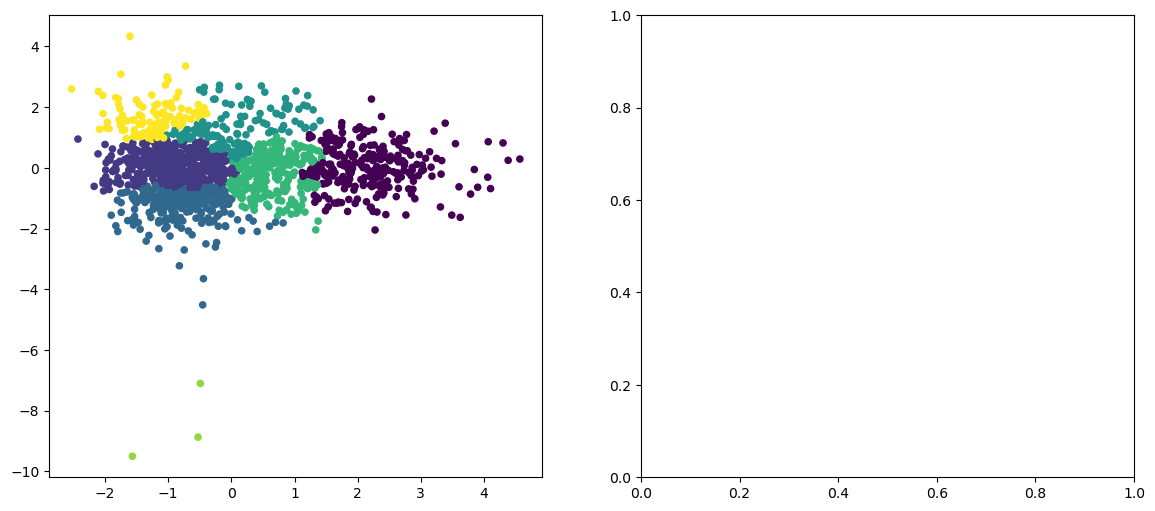

In [11]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

X = low_cn[["PC1", "PC2"]].values

clustering = AgglomerativeClustering(n_clusters=7)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=20)

c:\Users\karat\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\karat\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\karat\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\karat\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

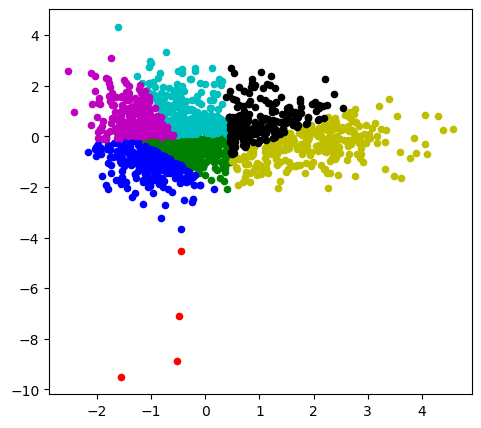

In [12]:
def divisive_clustering(data, max_clusters=7):
    clusters = [data]
    while len(clusters) < max_clusters:
        largest_idx = np.argmax([len(c) for c in clusters])
        cluster_to_split = clusters[largest_idx]
        clusters.pop(largest_idx)
        # cluster_to_split = max(clusters, key=lambda x: len(x))
        # clusters.remove(cluster_to_split)

        kmeans = KMeans(n_clusters=2, random_state=42).fit(cluster_to_split)
        cluster1 = cluster_to_split[kmeans.labels_ == 0]
        cluster2 = cluster_to_split[kmeans.labels_ == 1]

        clusters.extend([cluster1, cluster2])
    return clusters

X = low_cn[["PC1", "PC2"]].values
clusters = divisive_clustering(X, max_clusters=7)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], s=20,
                c=colors[i], label=f'Cluster {i+1}')

2


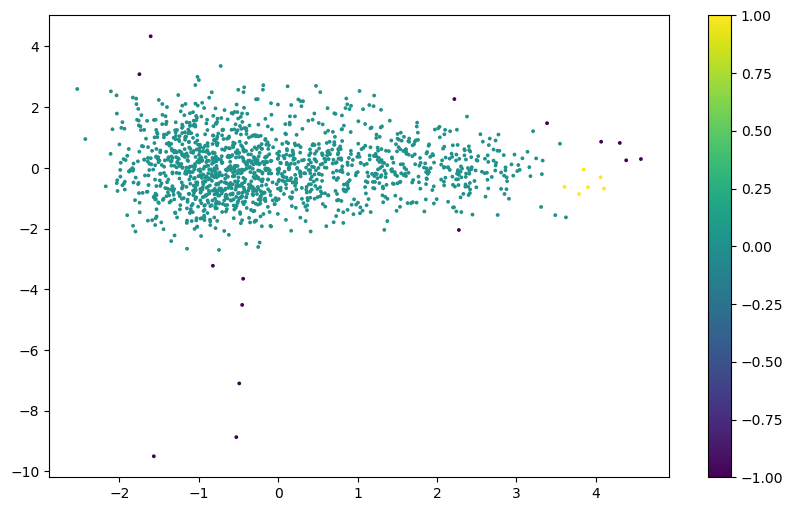

In [13]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
clusters = dbscan.fit_predict(X)
labels = dbscan.labels_
print(len(set(labels)) - (1 if -1 in labels else 0))
plt.figure(figsize=(10, 6))
scatter = plt.scatter(low_cn['PC1'], low_cn['PC2'], c=clusters, cmap='viridis', s=3)
plt.colorbar(scatter)
plt.show()